In [1]:
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ===============================
# LOAD DATA
# ===============================
df = pd.read_csv("telco_churn_7000.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00000,Male,0,Yes,No,17,Yes,Yes,No,No internet service,...,Yes,No internet service,Yes,No,One year,Yes,Bank transfer,106.09,1803.53,No
1,CUST00001,Female,1,No,No,58,No,No,No,No internet service,...,Yes,No internet service,Yes,No internet service,Two year,Yes,Mailed check,43.76,2538.08,No
2,CUST00002,Male,1,Yes,Yes,58,No,No,Fiber optic,Yes,...,No internet service,Yes,Yes,No internet service,Month-to-month,No,Electronic check,42.30,2453.40,Yes
3,CUST00003,Male,0,No,Yes,57,No,No phone service,No,No internet service,...,No internet service,No internet service,Yes,Yes,Month-to-month,No,Mailed check,58.78,3350.46,Yes
4,CUST00004,Male,1,Yes,Yes,7,Yes,No,Fiber optic,No,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer,37.26,260.82,No


In [3]:
print(df.shape)
print(df.info())
print(df.describe())

(7000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7000 non-null   object 
 1   gender            7000 non-null   object 
 2   SeniorCitizen     7000 non-null   int64  
 3   Partner           7000 non-null   object 
 4   Dependents        7000 non-null   object 
 5   tenure            7000 non-null   int64  
 6   PhoneService      7000 non-null   object 
 7   MultipleLines     7000 non-null   object 
 8   InternetService   7000 non-null   object 
 9   OnlineSecurity    7000 non-null   object 
 10  OnlineBackup      7000 non-null   object 
 11  DeviceProtection  7000 non-null   object 
 12  TechSupport       7000 non-null   object 
 13  StreamingTV       7000 non-null   object 
 14  StreamingMovies   7000 non-null   object 
 15  Contract          7000 non-null   object 
 16  PaperlessBilling  7000 non-null

In [4]:
# Drop customerID (not useful)
df.drop('customerID', axis=1, inplace=True)

# Convert TotalCharges to numeric (safety)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop missing values
df.dropna(inplace=True)

In [5]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
    

In [6]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

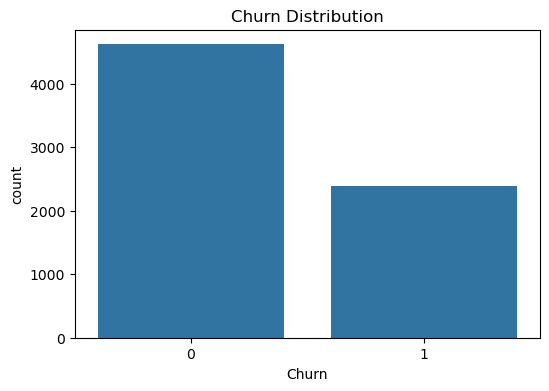

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

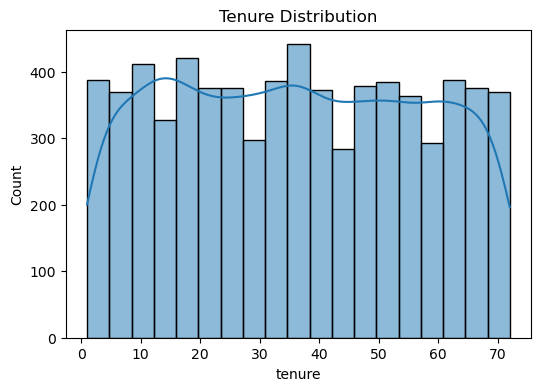

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df['tenure'], kde=True)
plt.title("Tenure Distribution")
plt.show()

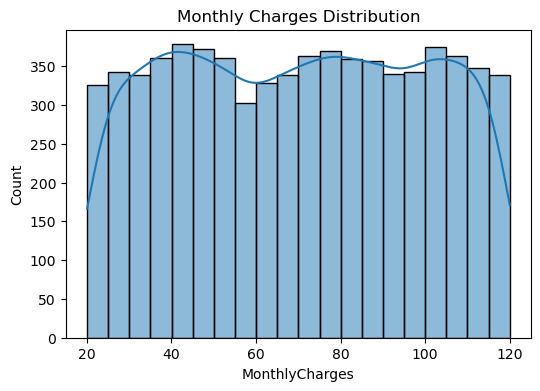

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df['MonthlyCharges'], kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

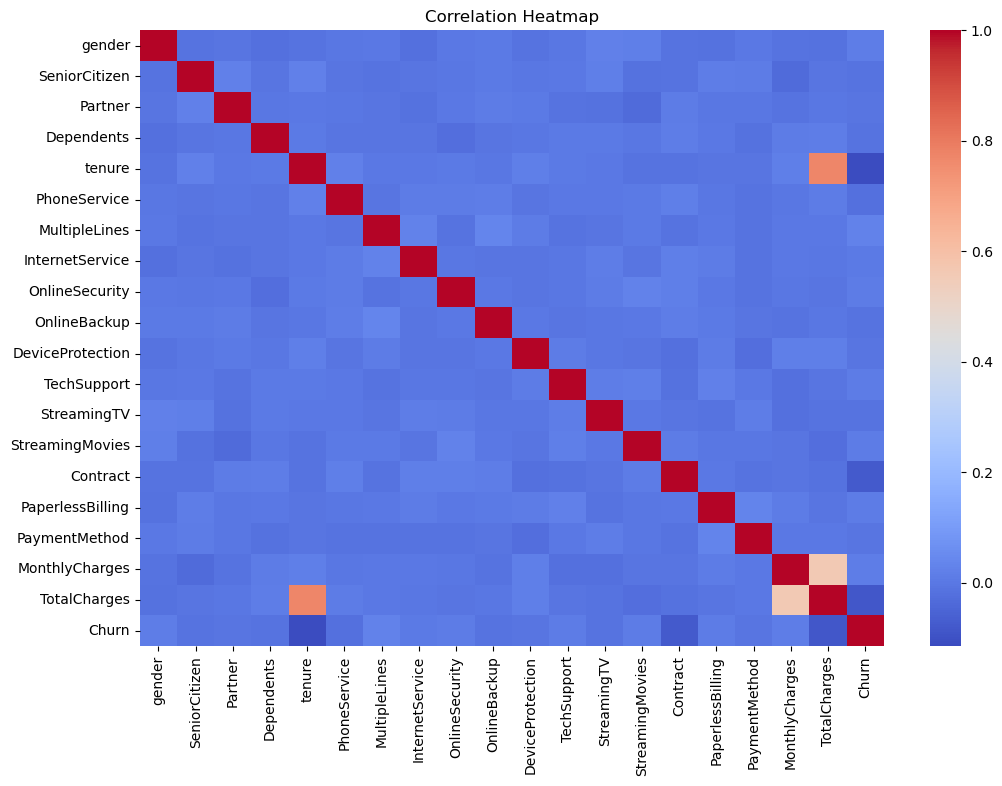

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

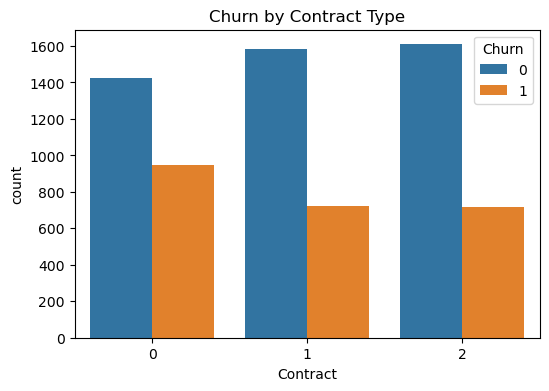

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

In [12]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [16]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [17]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [18]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.6607142857142857
Decision Tree Accuracy: 0.5792857142857143
Random Forest Accuracy: 0.6971428571428572


In [19]:
print("\nRandom Forest Report:\n")
print(classification_report(y_test, rf_pred))


Random Forest Report:

              precision    recall  f1-score   support

           0       0.69      0.98      0.81       911
           1       0.84      0.17      0.28       489

    accuracy                           0.70      1400
   macro avg       0.76      0.57      0.54      1400
weighted avg       0.74      0.70      0.62      1400



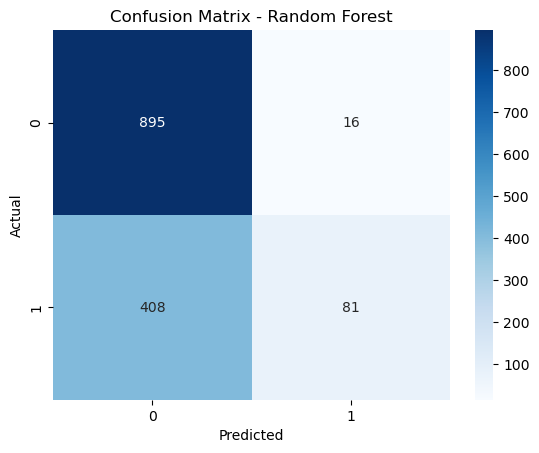

In [20]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

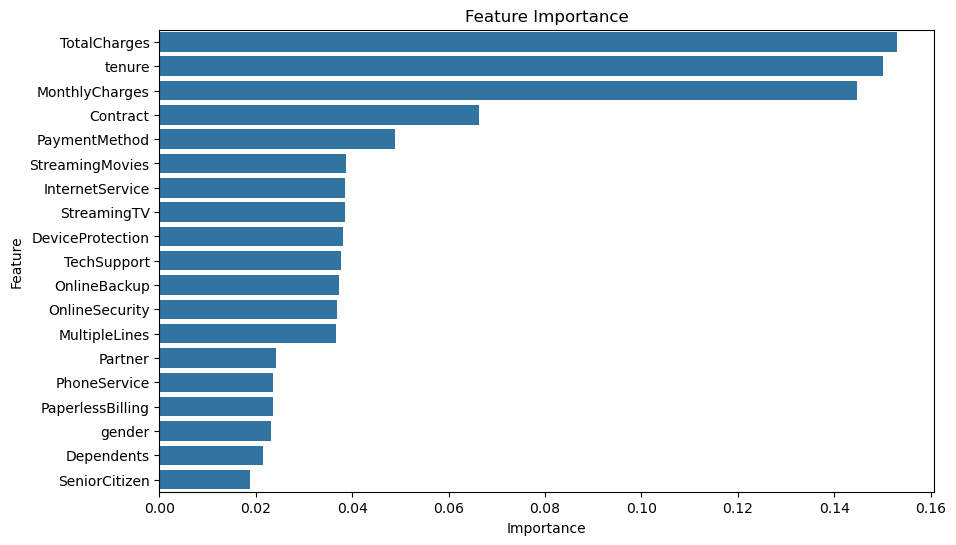

In [21]:
importances = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Feature Importance")
plt.show()

In [22]:
import joblib

joblib.dump(rf, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model & Scaler saved!")

Model & Scaler saved!
